# SGNS desde cero en PyTorch

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from gensim.test.utils import datapath

import utils as U
import sgns as S

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

CACHE = Path("cache")
ids = np.load(CACHE / "train_ids.npy")
offsets = np.load(CACHE / "train_offsets.npy")
vocab = U.load_vocab(CACHE / "vocab.json")
print(f"Corpus: {len(ids):,} tokens | vocabulario: {len(vocab):,}")

Dispositivo: cpu 
Corpus: 29,552,958 tokens | vocabulario: 109,646


## Evaluador por epoch

In [3]:
evaluator = S.Evaluator(
    vocab,
    analogies_path=datapath("questions-words.txt"),
    wordsim_path=datapath("wordsim353.tsv"),
    restrict=30000,
    device=device,
)
n_eval = sum(len(q) for q in evaluator.sections.values())
print(f"Analogías evaluables: {n_eval:,} / {sum(evaluator.totals.values()):,}")
print(f"Pares de WordSim-353 en vocabulario: {len(evaluator.ws_score)} / {evaluator.ws_total}")

Analogías evaluables: 11,796 / 19,544
Pares de WordSim-353 en vocabulario: 353 / 353


## Prueba de humo y calibración de tiempo

In [4]:
cfg = S.Config(name="humo", epochs=1, corpus_frac=0.05)
sub_ids, sub_off = S.take_fraction(ids, offsets, cfg.corpus_frac)
model, hist = S.train_sgns(sub_ids, sub_off, vocab, cfg, evaluator, device)
print(f"{hist['epochs'][0]['time_s']:.0f}s para {len(sub_ids):,} tokens")

[humo] epoch 1/1  loss 2.7580  29s  analogías sem/syn/total 0.011/0.007/0.009  WS353 0.035
           king: odaenathus, henry, calvert, brother, term
         france: italy, somalia, scotland, participated, secured
       computer: animation, steve, manga, content, moments
           good: felt, said, saying, something, things
        january: march, december, april, november, october
            run: hat-trick, finish, touchdown, bulls, rangers
29s para 1,477,574 tokens


## Experimentos
Base: dim=100 (comparable con GloVe), ventana 5, 5 negativos, submuestreo t=1e-4, 5 epochs.
- Barrido de **dimensión**: 50, 100, 300
- Barrido de **tamaño de corpus**: 25 %, 50 %, 100 % (dim=100)
- Otros hiperparámetros: ventana, negativos, submuestreo, learning rate

In [7]:
BASE = dict(dim=100, window=5, neg=5, subsample_t=1e-4, epochs=3, batch_size=4096, lr=3e-3)

def run(name, **over):
    if (CACHE / "runs" / f"{name}.json").exists():
        print(f"{name}: ya existe, se omite (borra el .json para repetirla)")
        return S.load_history(name)
    cfg = S.Config(name=name, **{**BASE, **over})
    i, o = S.take_fraction(ids, offsets, cfg.corpus_frac)
    print(f"\n=== {name} | {len(i):,} tokens | {cfg}")
    model, hist = S.train_sgns(i, o, vocab, cfg, evaluator, device)
    S.save_run(model, hist)
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return hist

### Iteración base 

In [8]:
run("d100_c100")


=== d100_c100 | 29,552,958 tokens | Config(name='d100_c100', dim=100, window=5, neg=5, subsample_t=0.0001, epochs=3, batch_size=4096, lr=0.003, min_lr_frac=0.01, corpus_frac=1.0, chunk_tokens=2000000, seed=42)
[d100_c100] epoch 1/3  loss 2.2827  634s  analogías sem/syn/total 0.197/0.325/0.287  WS353 0.616
           king: 1308, ecgberht, vi, edward, 1387
         france: italy, belgium, spain, netherlands, boulogne
       computer: computers, minicomputer, spacewar, computing, hack
           good: unpretty, darn, bad, awesomely, sure
        january: december, march, february, november, april
            run: inside-the-park, 2-run, running, three-run, 72-yard
[d100_c100] epoch 2/3  loss 2.1816  628s  analogías sem/syn/total 0.280/0.418/0.376  WS353 0.647
           king: rakoto, uncrowned, silkbeard, harefoot, maíl
         france: italy, belgium, spain, portugal, netherlands
       computer: computers, spacewar, software, minicomputer, computing
           good: bad, decent, darn, 

{'config': {'name': 'd100_c100',
  'dim': 100,
  'window': 5,
  'neg': 5,
  'subsample_t': 0.0001,
  'epochs': 3,
  'batch_size': 4096,
  'lr': 0.003,
  'min_lr_frac': 0.01,
  'corpus_frac': 1.0,
  'chunk_tokens': 2000000,
  'seed': 42},
 'n_tokens': 29552958,
 'vocab_size': 109646,
 'device': 'cpu',
 'epochs': [{'epoch': 1,
   'loss': 2.282743596086691,
   'lr_final': np.float64(0.002000104342018412),
   'pairs': 102405944,
   'time_s': 633.845566034317,
   'peak_gpu_mb': None,
   'analogy_sem': 0.19688826025459688,
   'analogy_syn': 0.3251422345962958,
   'analogy_total': 0.2867073584265853,
   'analogy_coverage': 0.6035611952517397,
   'analogy_per_section': {'capital-common-countries': 0.3526315789473684,
    'capital-world': 0.23290386521308226,
    'currency': 0.0,
    'city-in-state': 0.1,
    'family': 0.4444444444444444,
    'gram1-adjective-to-adverb': 0.06773399014778325,
    'gram2-opposite': 0.0661764705882353,
    'gram3-comparative': 0.38213213213213215,
    'gram4-super

### Barrido de dimensión

In [9]:
run("d50_c100", dim=50)
run("d300_c100", dim=300)


=== d50_c100 | 29,552,958 tokens | Config(name='d50_c100', dim=50, window=5, neg=5, subsample_t=0.0001, epochs=3, batch_size=4096, lr=0.003, min_lr_frac=0.01, corpus_frac=1.0, chunk_tokens=2000000, seed=42)
[d50_c100] epoch 1/3  loss 2.3203  282s  analogías sem/syn/total 0.133/0.239/0.207  WS353 0.569
           king: edward, hlothhere, giric, harthacnut, balliol
         france: italy, spain, belgium, austria, portugal
       computer: computers, software, spacewar, general-purpose, desktop
           good: tidy, plenty, cringe, selfishly, amazed
        january: december, march, february, april, november
            run: running, inside-the-park, hike, 18-yard, 75-yard
[d50_c100] epoch 2/3  loss 2.2230  273s  analogías sem/syn/total 0.178/0.321/0.278  WS353 0.594
           king: uncrowned, 1329, giric, tvrtko, sweyn
         france: italy, spain, austria, belgium, portugal
       computer: computers, spacewar, software, pdp-1, computing
           good: darn, tidy, amazed, heck, pl

{'config': {'name': 'd300_c100',
  'dim': 300,
  'window': 5,
  'neg': 5,
  'subsample_t': 0.0001,
  'epochs': 3,
  'batch_size': 4096,
  'lr': 0.003,
  'min_lr_frac': 0.01,
  'corpus_frac': 1.0,
  'chunk_tokens': 2000000,
  'seed': 42},
 'n_tokens': 29552958,
 'vocab_size': 109646,
 'device': 'cpu',
 'epochs': [{'epoch': 1,
   'loss': 2.2489257620659098,
   'lr_final': np.float64(0.002000104342018412),
   'pairs': 102405944,
   'time_s': 1194.0299520492554,
   'peak_gpu_mb': None,
   'analogy_sem': 0.2704384724186704,
   'analogy_syn': 0.386030746882944,
   'analogy_total': 0.3513903017972194,
   'analogy_coverage': 0.6035611952517397,
   'analogy_per_section': {'capital-common-countries': 0.4342105263157895,
    'capital-world': 0.31714568880079286,
    'currency': 0.0,
    'city-in-state': 0.1782857142857143,
    'family': 0.4649122807017544,
    'gram1-adjective-to-adverb': 0.07881773399014778,
    'gram2-opposite': 0.06985294117647059,
    'gram3-comparative': 0.44069069069069067,

### Barrido de tamaño de corpus

In [10]:
run("d100_c25", corpus_frac=0.25)
run("d100_c50", corpus_frac=0.50)


=== d100_c25 | 7,388,221 tokens | Config(name='d100_c25', dim=100, window=5, neg=5, subsample_t=0.0001, epochs=3, batch_size=4096, lr=0.003, min_lr_frac=0.01, corpus_frac=0.25, chunk_tokens=2000000, seed=42)
[d100_c25] epoch 1/3  loss 2.4083  177s  analogías sem/syn/total 0.081/0.085/0.084  WS353 0.487
           king: tailapa, 1135, justinian, castile, henry
         france: portugal, italy, spain, austria, germany
       computer: computers, programmers, hardware, third-party, self-published
           good: pretty, doing, damn, bullshit, easy
        january: february, october, december, march, july
            run: three-run, 50-yard, one-yard, 80-yard, 24-yard
[d100_c25] epoch 2/3  loss 2.2004  175s  analogías sem/syn/total 0.102/0.154/0.139  WS353 0.535
           king: murchad, 1158, 1157, tailapa, 1377
         france: spain, portugal, belgium, italy, netherlands
       computer: computers, pen-and-paper, self-published, desktop, ms-dos
           good: pretty, easy, decent, d

{'config': {'name': 'd100_c50',
  'dim': 100,
  'window': 5,
  'neg': 5,
  'subsample_t': 0.0001,
  'epochs': 3,
  'batch_size': 4096,
  'lr': 0.003,
  'min_lr_frac': 0.01,
  'corpus_frac': 0.5,
  'chunk_tokens': 2000000,
  'seed': 42},
 'n_tokens': 14776382,
 'vocab_size': 109646,
 'device': 'cpu',
 'epochs': [{'epoch': 1,
   'loss': 2.332893131065033,
   'lr_final': np.float64(0.002000006072721093),
   'pairs': 51181134,
   'time_s': 347.5823519229889,
   'peak_gpu_mb': None,
   'analogy_sem': 0.1340876944837341,
   'analogy_syn': 0.20578622442803535,
   'analogy_total': 0.18429976263140047,
   'analogy_coverage': 0.6035611952517397,
   'analogy_per_section': {'capital-common-countries': 0.1868421052631579,
    'capital-world': 0.13082259663032705,
    'currency': 0.0,
    'city-in-state': 0.08971428571428572,
    'family': 0.3333333333333333,
    'gram1-adjective-to-adverb': 0.027093596059113302,
    'gram2-opposite': 0.01838235294117647,
    'gram3-comparative': 0.23648648648648649

# Otros hiperparámetros

In [11]:
BASE["epochs"] = 3
for suf, over in [("w10", dict(window=10)), ("neg15", dict(neg=15)),
                  ("t1e-3", dict(subsample_t=1e-3)), ("lr1e-2", dict(lr=1e-2))]:
    run(f"d100_c25_{suf}", corpus_frac=0.25, **over)


=== d100_c25_w10 | 7,388,221 tokens | Config(name='d100_c25_w10', dim=100, window=10, neg=5, subsample_t=0.0001, epochs=3, batch_size=4096, lr=0.003, min_lr_frac=0.01, corpus_frac=0.25, chunk_tokens=2000000, seed=42)
[d100_c25_w10] epoch 1/3  loss 2.3527  322s  analogías sem/syn/total 0.074/0.109/0.098  WS353 0.511
           king: 1136, lancastrian, 1135, throne, gaveston
         france: spain, italy, stalinorgel, portugal, germany
       computer: simulator, simulation, computers, bédard, robinett
           good: cutaways, excitement, damn, pretty, enjoy
        january: february, december, october, november, march
            run: 27-yard, two-yard, 19-yard, 47-yard, 36-yard
[d100_c25_w10] epoch 2/3  loss 2.2042  322s  analogías sem/syn/total 0.108/0.187/0.163  WS353 0.563
           king: 1136, 1135, lancastrian, rhuddlan, throne
         france: spain, italy, lydda, netherlands, portugal
       computer: simulation, computers, simulator, pen-and-paper, cvg
           good: damn

## Resumen de iteraciones

In [12]:
runs = {p.stem: S.load_history(p.stem) for p in sorted((CACHE / "runs").glob("*.json"))
        if p.stem != "humo"}
filas = []
for name, h in runs.items():
    last, c = h["epochs"][-1], h["config"]
    filas.append(dict(
        corrida=name, tokens=h["n_tokens"], dim=c["dim"], ventana=c["window"], neg=c["neg"],
        t_submuestreo=c["subsample_t"], lr=c["lr"], epochs=c["epochs"],
        loss_final=round(last["loss"], 4),
        analog_sem=round(last["analogy_sem"], 3), analog_syn=round(last["analogy_syn"], 3),
        analog_total=round(last["analogy_total"], 3), wordsim353=round(last["wordsim353"], 3),
        tiempo_total_s=round(h["train_time_s"]), gpu_pico_mb=round(last["peak_gpu_mb"] or 0),
    ))
df_runs = pd.DataFrame(filas).set_index("corrida")
df_runs

,tokens,dim,ventana,neg,t_submuestreo,lr,epochs,loss_final,analog_sem,analog_syn,analog_total,wordsim353,tiempo_total_s,gpu_pico_mb
corrida,,,,,,,,,,,,,,
d100_c100,29552958,100,5,5,0.0001,0.003,3,2.1764,0.306,0.449,0.406,0.665,1906,0
d100_c25,7388221,100,5,5,0.0001,0.003,3,2.1613,0.111,0.181,0.160,0.544,528,0
d100_c25_lr1e-2,7388221,100,5,5,0.0001,0.010,3,2.0835,0.182,0.218,0.207,0.588,512,0
d100_c25_neg15,7388221,100,5,15,0.0001,0.003,3,3.1157,0.121,0.186,0.166,0.513,796,0
d100_c25_t1e-3,7388221,100,5,5,0.0010,0.003,3,2.1956,0.104,0.195,0.168,0.555,668,0
d100_c25_w10,7388221,100,10,5,0.0001,0.003,3,2.1828,0.120,0.215,0.187,0.575,964,0
d100_c50,14776382,100,5,5,0.0001,0.003,3,2.1662,0.217,0.327,0.294,0.607,1041,0
d300_c100,29552958,300,5,5,0.0001,0.003,3,2.1073,0.424,0.500,0.477,0.690,3650,0
d50_c100,29552958,50,5,5,0.0001,0.003,3,2.2222,0.202,0.342,0.300,0.607,830,0


In [13]:
for name, h in runs.items():
    print(f"--- {name}")
    for w, nbrs in h["epochs"][-1]["neighbors"].items():
        print(f"   {w:>9}: {', '.join(nbrs)}")

--- d100_c100
        king: oswine, uncrowned, rakoto, harefoot, maíl
      france: spain, italy, belgium, netherlands, portugal
    computer: computers, desktop, minicomputer, software, spacewar
        good: bad, darn, decent, excellent, pretty
     january: february, december, march, april, november
         run: inside-the-park, 2-run, running, bases-loaded, three-run
--- d100_c25
        king: murchad, tailapa, 1157, ballala, æthelred
      france: spain, italy, portugal, belgium, netherlands
    computer: computers, pen-and-paper, desktop, self-published, simulation
        good: pretty, decent, riddance, damn, bad
     january: october, february, june, march, november
         run: inside-the-park, three-run, walk-off, game-tying, 18-yard
--- d100_c25_lr1e-2
        king: rakoto, orseolo, 1157, 1033, brunswick-lüneburg
      france: spain, belgium, netherlands, italy, lunéville
    computer: computers, atari, software, ultima, point-and-click
        good: bad, excellent, pretty

## Curvas de pérdida y de accuracy de analogías por epoch

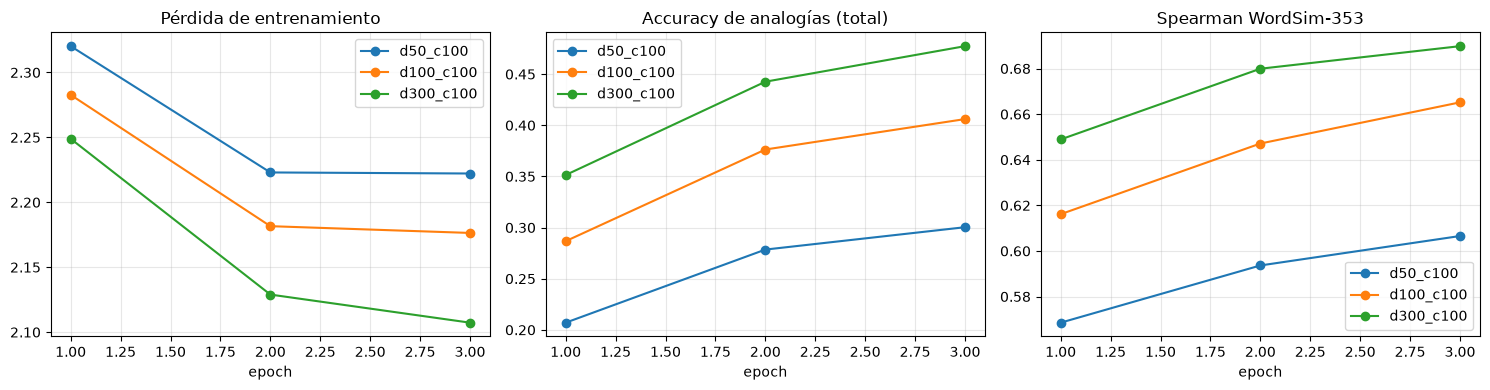

In [14]:
sel = ["d50_c100", "d100_c100", "d300_c100"]   # cambia por las iteraciones que quieras comparar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name in sel:
    h = runs[name]
    ep = [e["epoch"] for e in h["epochs"]]
    axes[0].plot(ep, [e["loss"] for e in h["epochs"]], "o-", label=name)
    axes[1].plot(ep, [e["analogy_total"] for e in h["epochs"]], "o-", label=name)
    axes[2].plot(ep, [e["wordsim353"] for e in h["epochs"]], "o-", label=name)
for ax, t in zip(axes, ["Pérdida de entrenamiento", "Accuracy de analogías (total)", "Spearman WordSim-353"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Validación cruzada de mi evaluador con gensim

In [15]:
from gensim.models import KeyedVectors

W = np.load(CACHE / "runs" / "d100_c100_W_in.npy")
kv = KeyedVectors(vector_size=W.shape[1])
kv.add_vectors(vocab.itos[2:], W[2:])
score, secs = kv.evaluate_word_analogies(datapath("questions-words.txt"),
                                         restrict_vocab=30000, case_insensitive=True)
mine = runs["d100_c100"]["epochs"][-1]["analogy_total"]
print(f"gensim: {score:.4f} | mi evaluador: {mine:.4f}")

gensim: 0.4061 | mi evaluador: 0.4061
